# Havi 2.0 — Pipeline Completo
### Hey Banco · Datathon 2026

**Entorno:** Visual Studio Code + extensión Jupyter

**Requisitos previos (solo una vez):**
```
pip install pandas numpy scikit-learn pyarrow matplotlib
```

**Estructura de carpetas esperada:**
```
tu-proyecto/
├── Havi_2_Pipeline.ipynb   ← este notebook
├── havi_mockup.html
└── DATASETS/
    ├── hey_clientes.csv
    ├── hey_productos.csv
    ├── hey_transacciones.csv
    └── hey_conversaciones.parquet
```

**Cómo correr:** abre este archivo en VS Code, selecciona tu kernel de Python y corre cada celda con `Shift+Enter`.

In [1]:
# ── CELDA 0 · Instalación de dependencias ───────────────────
# Corre esto solo la primera vez. Después puedes comentarlo.
import subprocess, sys

paquetes = ['pandas', 'numpy', 'scikit-learn', 'pyarrow', 'matplotlib']
for pkg in paquetes:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    print(f'  ✓ {pkg}')

print('\n✅ Dependencias listas')

  ✓ pandas
  ✓ numpy
  ✓ scikit-learn
  ✓ pyarrow
  ✓ matplotlib

✅ Dependencias listas


In [2]:
# ── CELDA 1 · Imports ────────────────────────────────────────
import pandas as pd
import numpy as np
import re, json, warnings
from pathlib import Path
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✓ Imports OK')

✓ Imports OK


In [3]:
# ── CELDA 2 · Rutas de los datasets ─────────────────────────
# Ajusta CARPETA_DATOS si tu carpeta tiene otro nombre o ruta.
# Path('.') apunta a la carpeta donde está este notebook.

CARPETA_DATOS = Path('.') / 'DATASETS'

ARCHIVO_CLIENTES       = CARPETA_DATOS / 'hey_clientes.csv'
ARCHIVO_PRODUCTOS      = CARPETA_DATOS / 'hey_productos.csv'
ARCHIVO_TRANSACCIONES  = CARPETA_DATOS / 'hey_transacciones.csv'
ARCHIVO_CONVERSACIONES = CARPETA_DATOS / 'hey_conversaciones.parquet'

# Verificar que los archivos existen antes de continuar
archivos = {
    'clientes':       ARCHIVO_CLIENTES,
    'productos':      ARCHIVO_PRODUCTOS,
    'transacciones':  ARCHIVO_TRANSACCIONES,
    'conversaciones': ARCHIVO_CONVERSACIONES,
}
todos_ok = True
for nombre, ruta in archivos.items():
    if ruta.exists():
        print(f'  ✓  {nombre}: {ruta}')
    else:
        print(f'  ✗  {nombre} NO encontrado en: {ruta.resolve()}')
        todos_ok = False

if todos_ok:
    print('\n✅ Todos los archivos encontrados. Puedes continuar.')
else:
    print('\n⚠  Corrige las rutas antes de continuar.')

  ✓  clientes: DATASETS\hey_clientes.csv
  ✓  productos: DATASETS\hey_productos.csv
  ✓  transacciones: DATASETS\hey_transacciones.csv
  ✓  conversaciones: DATASETS\hey_conversaciones.parquet

✅ Todos los archivos encontrados. Puedes continuar.


In [4]:
# ── CELDA 3 · Carga de los 4 datasets ───────────────────────
def cargar(ruta, requerido=True):
    ruta = Path(ruta)
    try:
        if ruta.suffix == '.parquet':
            df = pd.read_parquet(ruta)
        else:
            df = pd.read_csv(ruta)
        print(f'  ✓  {ruta.name}: {len(df):,} filas · {df.shape[1]} cols')
        return df
    except FileNotFoundError:
        if requerido:
            raise FileNotFoundError(f'No encontré: {ruta.resolve()}')
        print(f'  ⚠  {ruta.name} no encontrado — módulo NLP desactivado')
        return None

print('Cargando datasets...')
clientes      = cargar(ARCHIVO_CLIENTES)
productos     = cargar(ARCHIVO_PRODUCTOS)
transacciones = cargar(ARCHIVO_TRANSACCIONES)
conv          = cargar(ARCHIVO_CONVERSACIONES, requerido=False)

TIENE_CONV = conv is not None
if TIENE_CONV:
    conv['date'] = pd.to_datetime(conv['date'], errors='coerce')
transacciones['fecha_hora'] = pd.to_datetime(transacciones['fecha_hora'], errors='coerce')

print(f'\n✅ {"4" if TIENE_CONV else "3"} datasets cargados')

Cargando datasets...
  ✓  hey_clientes.csv: 15,025 filas · 22 cols
  ✓  hey_productos.csv: 38,909 filas · 13 cols
  ✓  hey_transacciones.csv: 802,384 filas · 22 cols
  ✓  hey_conversaciones.parquet: 49,999 filas · 6 cols

✅ 4 datasets cargados


In [5]:
# ── CELDA 4 · EDA rápido — estado inicial ────────────────────
print('='*55)
for nombre, df in {'clientes': clientes, 'productos': productos,
                    'transacciones': transacciones}.items():
    print(f'\n📋 {nombre.upper()}')
    print(f'   Shape:      {df.shape}')
    print(f'   Dupes:      {df.duplicated().sum()}')
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print(f'   Nulos:\n{nulls[nulls>0].to_string()}')
    else:
        print('   Nulos:      ninguno')

if TIENE_CONV:
    print(f'\n📋 CONVERSACIONES')
    print(f'   Shape:      {conv.shape}')
    print(f'   Usuarios:   {conv["user_id"].nunique():,}')
    if 'channel_source' in conv.columns:
        print(f'   Canales:\n{conv["channel_source"].value_counts().to_string()}')

print('\n' + '='*55)
ub = set(clientes['user_id'])
up = set(productos['user_id'])
ut = set(transacciones['user_id'])
print(f'Usuarios sin productos:      {len(ub-up):,}')
print(f'Usuarios sin transacciones:  {len(ub-ut):,}')
if TIENE_CONV:
    uc = set(conv['user_id'])
    print(f'Usuarios sin conversaciones: {len(ub-uc):,}')


📋 CLIENTES
   Shape:      (15025, 22)
   Dupes:      0
   Nulos:
estado               432
ciudad               432
satisfaccion_1_10    751

📋 PRODUCTOS
   Shape:      (38909, 13)
   Dupes:      0
   Nulos:
limite_credito        24592
saldo_actual           3750
utilizacion_pct       24592
tasa_interes_anual    20118
plazo_meses           34359
monto_mensualidad     34359

📋 TRANSACCIONES
   Shape:      (802384, 22)
   Dupes:      0
   Nulos:
comercio_nombre        370538
ciudad_transaccion      19267
motivo_no_procesada    775775
meses_diferidos        785071
cashback_generado      621746
descripcion_libre       61752
dispositivo            202063

📋 CONVERSACIONES
   Shape:      (49999, 6)
   Usuarios:   15,025
   Canales:
channel_source
1    46936
2     3063

Usuarios sin productos:      0
Usuarios sin transacciones:  0
Usuarios sin conversaciones: 0


In [6]:
# ── CELDA 5 · Limpieza — normalización y valores imposibles ──
for col in ['tipo_producto','estatus','canal','categoria_mcc','tipo_operacion']:
    for df in [transacciones, productos]:
        if col in df.columns:
            df[col] = df[col].str.lower().str.strip()

domain_rules = {
    'monto':           (0,    None),
    'edad':            (18,   90),
    'ingreso_mensual': (0,    None),
    'score_buro':      (300,  850),
    'limite_credito':  (0,    None),
}
total_invalidos = 0
for col, (lo, hi) in domain_rules.items():
    for df in [clientes, productos, transacciones]:
        if col not in df.columns: continue
        mask = pd.Series(False, index=df.index)
        if lo is not None: mask |= df[col] < lo
        if hi is not None: mask |= df[col] > hi
        n = mask.sum()
        if n > 0:
            df.loc[mask, col] = np.nan
            total_invalidos += n
            print(f'  {col}: {n} valores imposibles → NaN')

for col in ['limite_credito','cashback_generado','monto']:
    for df in [transacciones, productos]:
        if col in df.columns:
            df[col] = df[col].fillna(0)

for col in ['ingreso_mensual','score_buro','edad']:
    if col in clientes.columns:
        clientes[col] = clientes[col].fillna(clientes[col].median())

print(f'\n✅ Limpieza lista — {total_invalidos} valores imposibles corregidos')

  score_buro: 27 valores imposibles → NaN

✅ Limpieza lista — 27 valores imposibles corregidos


In [7]:
# ── CELDA 6 · Features transaccionales ──────────────────────
FECHA_REF = transacciones['fecha_hora'].max()

txn_feats = transacciones.groupby('user_id').agg(
    txn_total       = ('monto', 'count'),
    ticket_prom     = ('monto', 'mean'),
    monto_total     = ('monto', 'sum'),
    dias_ultima_txn = ('fecha_hora', lambda x: max((FECHA_REF - x.max()).days, 0)),
).reset_index()

if 'cashback_generado' in transacciones.columns:
    cb = transacciones.groupby('user_id')['cashback_generado'].sum().rename('cashback_total').reset_index()
    txn_feats = txn_feats.merge(cb, on='user_id', how='left')

if 'categoria_mcc' in transacciones.columns:
    div = transacciones.groupby('user_id')['categoria_mcc'].nunique().rename('diversidad_mcc').reset_index()
    txn_feats = txn_feats.merge(div, on='user_id', how='left')

if 'estatus' in transacciones.columns:
    fallo = (
        transacciones
        .assign(es_fallo=lambda d: (d['estatus']=='no_procesada').astype(int))
        .groupby('user_id')['es_fallo'].mean()
        .rename('tasa_txn_fallida').reset_index()
    )
    txn_feats = txn_feats.merge(fallo, on='user_id', how='left')

if 'hora_del_dia' in transacciones.columns:
    transacciones['franja'] = pd.cut(
        transacciones['hora_del_dia'], bins=[-1,11,18,23], labels=[0,1,2]
    ).astype(float)
    horario = (
        transacciones.groupby('user_id')['franja']
        .agg(lambda x: x.mode()[0] if len(x)>0 else 1)
        .rename('horario_preferido').reset_index()
    )
    txn_feats = txn_feats.merge(horario, on='user_id', how='left')

if 'categoria_mcc' in transacciones.columns:
    top_mcc = transacciones['categoria_mcc'].value_counts().head(5).index.tolist()
    monto_usr = transacciones.groupby('user_id')['monto'].sum()
    for mcc in top_mcc:
        col = f"pct_{re.sub(r'[^a-z0-9]','_',str(mcc))[:18]}"
        s = (transacciones[transacciones['categoria_mcc']==mcc]
             .groupby('user_id')['monto'].sum().div(monto_usr).fillna(0).rename(col))
        txn_feats = txn_feats.merge(s.reset_index(), on='user_id', how='left')

if 'canal' in transacciones.columns:
    dig = (
        transacciones
        .assign(digital=lambda d: d['canal'].isin(['app','web','online','digital']).astype(int))
        .groupby('user_id')['digital'].mean()
        .rename('ratio_digital').reset_index()
    )
    txn_feats = txn_feats.merge(dig, on='user_id', how='left')

if 'patron_uso_atipico' in transacciones.columns:
    at = transacciones.groupby('user_id')['patron_uso_atipico'].max().rename('patron_atipico_txn').reset_index()
    txn_feats = txn_feats.merge(at, on='user_id', how='left')

print(f'✅ Features transaccionales: {txn_feats.shape[1]-1} columnas')
txn_feats.head(3)

✅ Features transaccionales: 15 columnas


,user_id,txn_total,ticket_prom,monto_total,dias_ultima_txn,cashback_total,diversidad_mcc,tasa_txn_fallida,horario_preferido,pct_transferencia,pct_servicios_digitale,pct_restaurante,pct_supermercado,pct_gobierno,ratio_digital,patron_atipico_txn
0,USR-00001,56,2135.1891,119570.5900,23,122.3300,7,0.0536,0.0000,0.8385,0.0558,0.0505,0.0070,0.0172,0.0000,False
1,USR-00002,74,2874.6307,212722.6700,18,147.0800,7,0.0135,0.0000,0.9020,0.0301,0.0379,0.0066,0.0000,0.0000,False
2,USR-00003,79,2415.2037,190801.0900,20,165.4300,8,0.0506,0.0000,0.8329,0.0473,0.0245,0.0029,0.0541,0.0000,False


In [8]:
# ── CELDA 7 · Features de productos ─────────────────────────
prod_feats = productos.groupby('user_id').agg(
    num_productos_total   = ('producto_id', 'count'),
    num_productos_activos = ('estatus', lambda x: (x=='activo').sum()),
).reset_index()

if 'saldo' in productos.columns:
    sp = productos.groupby('user_id')['saldo'].mean().rename('saldo_promedio').reset_index()
    prod_feats = prod_feats.merge(sp, on='user_id', how='left')

if 'limite_credito' in productos.columns:
    lc = productos.groupby('user_id')['limite_credito'].sum().rename('limite_credito_total').reset_index()
    prod_feats = prod_feats.merge(lc, on='user_id', how='left')

if 'tipo_producto' in productos.columns:
    dp = productos.groupby('user_id')['tipo_producto'].nunique().rename('diversidad_productos').reset_index()
    prod_feats = prod_feats.merge(dp, on='user_id', how='left')

if all(c in productos.columns for c in ['saldo','limite_credito']):
    util = (
        productos[productos['limite_credito']>0]
        .assign(util=lambda d: d['saldo']/d['limite_credito'])
        .groupby('user_id')['util'].mean()
        .rename('utilizacion_credito').reset_index()
    )
    prod_feats = prod_feats.merge(util, on='user_id', how='left')

if 'tipo_producto' in productos.columns:
    seg = (
        productos.groupby('user_id')['tipo_producto']
        .apply(lambda x: int(x.str.contains('seguro',na=False).any()))
        .rename('tiene_seguro').reset_index()
    )
    prod_feats = prod_feats.merge(seg, on='user_id', how='left')

print(f'✅ Features de productos: {prod_feats.shape[1]-1} columnas')
prod_feats.head(3)

✅ Features de productos: 5 columnas


,user_id,num_productos_total,num_productos_activos,limite_credito_total,diversidad_productos,tiene_seguro
0,USR-00001,2,2,144000.0000,2,0
1,USR-00002,2,2,22000.0000,2,0
2,USR-00003,2,2,5000.0000,2,0


In [9]:
# ── CELDA 8 · Features NLP de conversaciones ────────────────
conv_feats = None

if TIENE_CONV:
    def limpiar(t):
        if pd.isna(t): return ''
        t = str(t).lower()
        t = re.sub(r'\\n|\\t|<[^>]+>', ' ', t)
        t = re.sub(r'[^\w\sáéíóúüñ]', ' ', t)
        return re.sub(r'\s+', ' ', t).strip()

    conv['input_clean'] = conv['input'].apply(limpiar)

    FECHA_REF_CONV = conv['date'].max()
    vol = conv.groupby('user_id').agg(
        num_conversaciones = ('conv_id', 'nunique') if 'conv_id' in conv.columns else ('input','count'),
        num_mensajes_conv  = ('input', 'count'),
        dias_ultima_conv   = ('date', lambda x: max((FECHA_REF_CONV - x.max()).days, 0)),
        avg_len_input      = ('input_clean', lambda x: x.str.len().mean()),
    ).reset_index()

    if 'channel_source' in conv.columns:
        canal_map = {c:i for i,c in enumerate(conv['channel_source'].value_counts().index)}
        canal_pref = (
            conv.groupby('user_id')['channel_source']
            .agg(lambda x: x.value_counts().index[0])
            .map(canal_map).rename('canal_conv_num').reset_index()
        )
        vol = vol.merge(canal_pref, on='user_id', how='left')

    intenciones = {
        'pagos':    ['pago','pagar','transferencia','cargo','spei','cobro'],
        'credito':  ['credito','limite','tarjeta','deuda','interes','corte'],
        'soporte':  ['problema','error','falla','no funciona','bloqueo','queja'],
        'producto': ['seguro','ahorro','hey pro','cashback','beneficio'],
        'saldo':    ['saldo','disponible','cuanto tengo','cuenta'],
    }
    def detectar(t):
        s = {k: sum(1 for w in v if w in t) for k,v in intenciones.items()}
        b = max(s, key=s.get)
        return b if s[b]>0 else 'otro'

    conv['intencion'] = conv['input_clean'].apply(detectar)
    intent_pct = (
        conv.groupby(['user_id','intencion']).size().unstack(fill_value=0)
        .div(conv.groupby('user_id').size(), axis=0)
    )
    intent_pct.columns = [f'pct_intent_{c}' for c in intent_pct.columns]

    palabras_neg = ['malo','terrible','horrible','no funciona','molesto',
                    'enojado','fraude','pesimo','queja','cancelar']
    conv['es_neg'] = conv['input_clean'].apply(lambda t: int(any(w in t for w in palabras_neg)))
    sent = conv.groupby('user_id')['es_neg'].mean().rename('pct_msgs_negativos').reset_index()

    conv_feats = (
        vol
        .merge(intent_pct.reset_index(), on='user_id', how='left')
        .merge(sent, on='user_id', how='left')
    ).fillna(0)

    print(f'✅ Features NLP: {conv_feats.shape[1]-1} columnas')
    display(conv_feats.head(3))
else:
    print('⚠  Sin conversaciones — features NLP omitidos')

✅ Features NLP: 12 columnas


,user_id,num_conversaciones,num_mensajes_conv,dias_ultima_conv,avg_len_input,canal_conv_num,pct_intent_credito,pct_intent_otro,pct_intent_pagos,pct_intent_producto,pct_intent_saldo,pct_intent_soporte,pct_msgs_negativos
0,USR-00001,1,3,112.0000,42.6667,0,0.3333,0.3333,0.3333,0.0000,0.0000,0.0000,0.0000
1,USR-00002,1,3,71.0000,32.6667,0,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,USR-00003,1,3,47.0000,44.3333,0,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [10]:
# ── CELDA 9 · Join final → tabla maestra (1 fila / usuario) ─
demo_cols = ['user_id','edad','ingreso_mensual','score_buro',
             'nps','es_hey_pro','patron_uso_atipico']
demo = clientes[[c for c in demo_cols if c in clientes.columns]].copy()
if 'es_hey_pro' in demo.columns:
    demo['es_hey_pro'] = demo['es_hey_pro'].astype(float)

features = demo.merge(prod_feats,  on='user_id', how='left')
features = features.merge(txn_feats,  on='user_id', how='left')
if conv_feats is not None:
    features = features.merge(conv_feats, on='user_id', how='left')

features = features.fillna(0)

print(f'✅ Tabla maestra: {features.shape[0]:,} usuarios × {features.shape[1]} columnas')
print(f'   Fuentes: demográfico + productos + transacciones{" + NLP" if conv_feats is not None else ""}')
display(features.head(3))

✅ Tabla maestra: 15,025 usuarios × 37 columnas
   Fuentes: demográfico + productos + transacciones + NLP


,user_id,edad,score_buro,es_hey_pro,patron_uso_atipico,num_productos_total,num_productos_activos,limite_credito_total,diversidad_productos,tiene_seguro,txn_total,ticket_prom,monto_total,dias_ultima_txn,cashback_total,diversidad_mcc,tasa_txn_fallida,horario_preferido,pct_transferencia,pct_servicios_digitale,pct_restaurante,pct_supermercado,pct_gobierno,ratio_digital,patron_atipico_txn,num_conversaciones,num_mensajes_conv,dias_ultima_conv,avg_len_input,canal_conv_num,pct_intent_credito,pct_intent_otro,pct_intent_pagos,pct_intent_producto,pct_intent_saldo,pct_intent_soporte,pct_msgs_negativos
0,USR-00001,21,527.0000,1.0000,False,2,2,144000.0000,2,0,56,2135.1891,119570.5900,23,122.3300,7,0.0536,0.0000,0.8385,0.0558,0.0505,0.0070,0.0172,0.0000,False,1,3,112.0000,42.6667,0,0.3333,0.3333,0.3333,0.0000,0.0000,0.0000,0.0000
1,USR-00002,18,714.0000,1.0000,False,2,2,22000.0000,2,0,74,2874.6307,212722.6700,18,147.0800,7,0.0135,0.0000,0.9020,0.0301,0.0379,0.0066,0.0000,0.0000,False,1,3,71.0000,32.6667,0,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,USR-00003,23,454.0000,1.0000,False,2,2,5000.0000,2,0,79,2415.2037,190801.0900,20,165.4300,8,0.0506,0.0000,0.8329,0.0473,0.0245,0.0029,0.0541,0.0000,False,1,3,47.0000,44.3333,0,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000


Evaluando k...
  k=2 | inercia=465,799 | silhouette=0.1166
  k=3 | inercia=436,097 | silhouette=0.1082
  k=4 | inercia=411,216 | silhouette=0.1165
  k=5 | inercia=392,761 | silhouette=0.1196
  k=6 | inercia=375,286 | silhouette=0.1068
  k=7 | inercia=365,583 | silhouette=0.1124


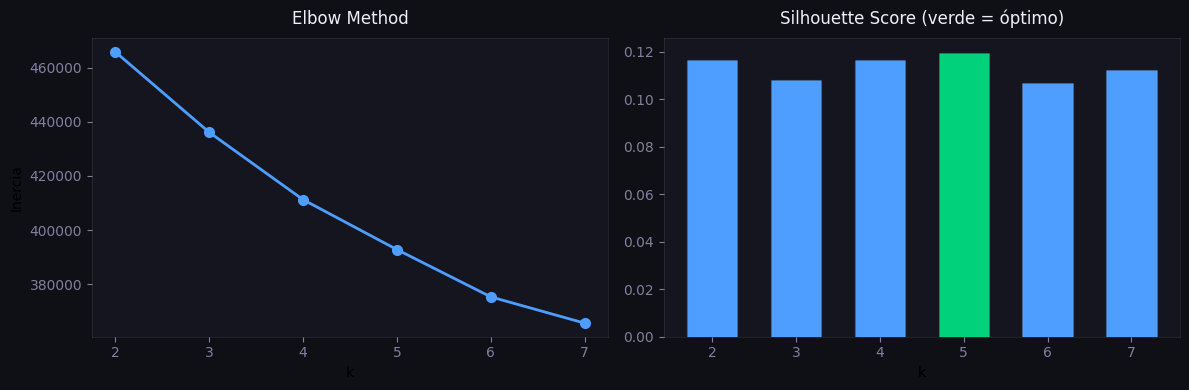


✅ k óptimo = 5 · silhouette = 0.1196


In [11]:
# ── CELDA 10 · Clustering K-Means ───────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#0F0F16'
matplotlib.rcParams['axes.facecolor']   = '#151520'
matplotlib.rcParams['axes.edgecolor']   = '#ffffff14'
matplotlib.rcParams['text.color']       = '#EEEEF8'
matplotlib.rcParams['xtick.color']      = '#8080A0'
matplotlib.rcParams['ytick.color']      = '#8080A0'

X = features.drop(columns=['user_id'])
X = X.loc[:, X.std() > 0]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_range    = range(2, 8)
inercias   = []
sil_scores = {}

print('Evaluando k...')
for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    sil_scores[k] = round(silhouette_score(X_scaled, lbl), 4)
    print(f'  k={k} | inercia={km.inertia_:,.0f} | silhouette={sil_scores[k]}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(k_range), inercias, 'o-', color='#4D9EFF', linewidth=2, markersize=7)
ax1.set_title('Elbow Method', pad=10)
ax1.set_xlabel('k')
ax1.set_ylabel('Inercia')

colors = ['#00D17A' if sil_scores[k]==max(sil_scores.values()) else '#4D9EFF' for k in k_range]
ax2.bar(list(k_range), list(sil_scores.values()), color=colors, width=0.6, edgecolor='#ffffff14')
ax2.set_title('Silhouette Score (verde = óptimo)', pad=10)
ax2.set_xlabel('k')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight', facecolor='#0F0F16')
plt.show()

K_OPTIMO = max(sil_scores, key=sil_scores.get)
BEST_SIL = sil_scores[K_OPTIMO]
print(f'\n✅ k óptimo = {K_OPTIMO} · silhouette = {BEST_SIL}')

✅ Clusters asignados (k=5)
   Varianza explicada PCA: 23.7%


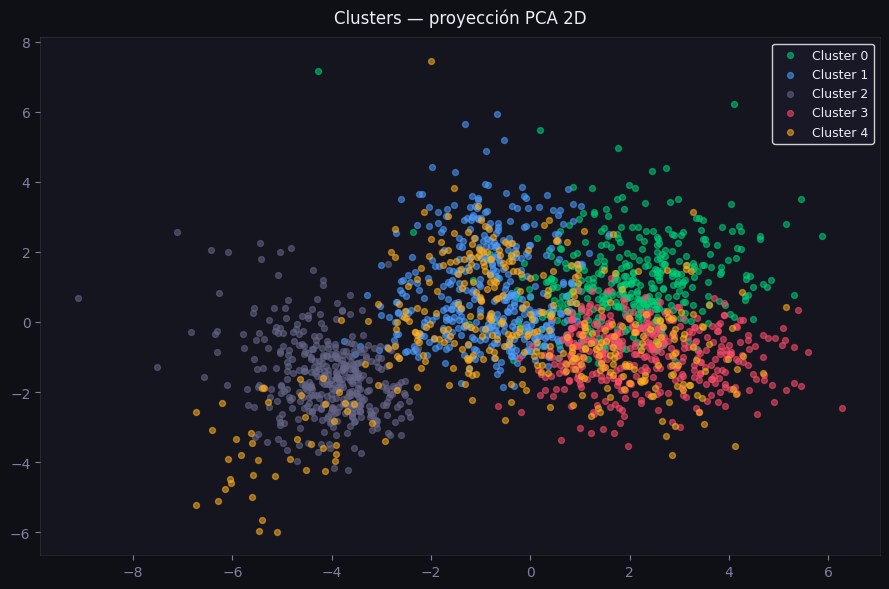


Distribución:
  Cluster 0: 1,398 usuarios (9.3%)
  Cluster 1: 6,649 usuarios (44.3%)
  Cluster 2: 1,746 usuarios (11.6%)
  Cluster 3: 4,473 usuarios (29.8%)
  Cluster 4: 759 usuarios (5.1%)


In [12]:
# ── CELDA 11 · Modelo final + PCA 2D ────────────────────────
km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=20)
features['cluster'] = km_final.fit_predict(X_scaled)

pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
features['pca_x'] = coords[:,0].round(4)
features['pca_y'] = coords[:,1].round(4)

print(f'✅ Clusters asignados (k={K_OPTIMO})')
print(f'   Varianza explicada PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%')

PALETA = ['#00D17A','#4D9EFF','#666688','#FF4D6A','#FFB020','#9B6EFF']
fig, ax = plt.subplots(figsize=(9, 6))
for c in sorted(features['cluster'].unique()):
    sub = features[features['cluster']==c].head(400)
    ax.scatter(sub['pca_x'], sub['pca_y'],
               c=PALETA[c % len(PALETA)], alpha=0.55, s=18, label=f'Cluster {c}')
ax.legend(facecolor='#1A1A28', edgecolor='#ffffff14', labelcolor='#EEEEF8', fontsize=9)
ax.set_title('Clusters — proyección PCA 2D', pad=10)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight', facecolor='#0F0F16')
plt.show()

print('\nDistribución:')
dist = features['cluster'].value_counts().sort_index()
for c, n in dist.items():
    print(f'  Cluster {c}: {n:,} usuarios ({n/len(features)*100:.1f}%)')

In [13]:
# ── CELDA 12 · Perfiles y naming de clusters ─────────────────
profile_cols = [c for c in [
    'ticket_prom','tasa_txn_fallida','num_productos_activos',
    'utilizacion_credito','dias_ultima_txn','cashback_total',
    'es_hey_pro','pct_msgs_negativos','num_conversaciones','ingreso_mensual'
] if c in features.columns]

centros = features.groupby('cluster')[profile_cols].mean().round(3)
display(centros)

def nombre_cluster(row):
    s = {
        'dormido': row.get('dias_ultima_txn',0)*2 + (1 if row.get('num_conversaciones',1)<1 else 0),
        'riesgo':  row.get('tasa_txn_fallida',0)*5 + row.get('pct_msgs_negativos',0)*3,
        'negocio': row.get('num_productos_activos',0)*3 + row.get('ticket_prom',0)/1000,
        'nomina':  max(0,(35-row.get('edad',30))/10) + (1 if row.get('tasa_txn_fallida',0)<0.05 else 0),
    }
    return max(s, key=s.get)

nombres_map = {
    'nomina':  ('Nómina joven',   '#00D17A','💳'),
    'negocio': ('Negocio activo', '#4D9EFF','🏢'),
    'dormido': ('Usuario dormido','#666688','💤'),
    'riesgo':  ('Alto riesgo',    '#FF4D6A','⚠️'),
}
CLUSTER_INFO = {}
usados = set()
for idx, row in centros.iterrows():
    tipo = nombre_cluster(row.to_dict())
    if tipo in usados: tipo = f'otro_{idx}'
    usados.add(tipo)
    nm, col, ic = nombres_map.get(tipo, (f'Cluster {idx}','#888','📊'))
    CLUSTER_INFO[int(idx)] = {'tipo':tipo,'nombre':nm,'color':col,'icon':ic}
    n = (features['cluster']==idx).sum()
    print(f'  {ic}  Cluster {idx} → {nm} ({n:,} usuarios · {n/len(features)*100:.1f}%)')

,ticket_prom,tasa_txn_fallida,num_productos_activos,dias_ultima_txn,cashback_total,es_hey_pro,pct_msgs_negativos,num_conversaciones
cluster,,,,,,,,
0,8141.7530,0.0250,2.9960,21.4230,682.1730,0.4340,0.0360,1.5570
1,3675.5080,0.0460,1.8680,19.7300,75.2900,0.4800,0.0410,1.6080
2,4266.5730,0.0270,0.7290,48.5710,1.7240,0.0840,0.0430,1.6060
3,9437.1390,0.0250,3.1310,20.5540,243.7880,0.6800,0.0420,1.6200
4,5771.4070,0.0360,2.1880,41.2570,162.1100,0.4730,0.0500,1.5810


  💤  Cluster 0 → Usuario dormido (1,398 usuarios · 9.3%)
  📊  Cluster 1 → Cluster 1 (6,649 usuarios · 44.3%)
  📊  Cluster 2 → Cluster 2 (1,746 usuarios · 11.6%)
  📊  Cluster 3 → Cluster 3 (4,473 usuarios · 29.8%)
  📊  Cluster 4 → Cluster 4 (759 usuarios · 5.1%)


In [14]:
# ── CELDA 12B · Nombrar clusters manualmente ─────────────────
# Revisa la tabla de arriba y asigna el nombre que mejor describe cada cluster.
# Opciones de tipo: 'nomina', 'negocio', 'dormido', 'riesgo'
# Si usas otro tipo, el mockup mostrará el nombre e ícono que pongas aquí.

NOMBRES_MANUALES = {
    0: {'tipo': 'dormido', 'nombre': 'Usuario dormido', 'color': '#666688', 'icon': '💤'},
    1: {'tipo': 'nomina',  'nombre': 'Nómina joven',    'color': '#00D17A', 'icon': '💳'},
    2: {'tipo': 'negocio', 'nombre': 'Negocio activo',  'color': '#4D9EFF', 'icon': '🏢'},
    3: {'tipo': 'riesgo',  'nombre': 'Alto riesgo',     'color': '#FF4D6A', 'icon': '⚠️'},
    4: {'tipo': 'nomina',  'nombre': 'Nómina joven 2',  'color': '#00C4B4', 'icon': '💳'},
}

# Sobreescribir el CLUSTER_INFO con los nombres manuales
for cid, info in NOMBRES_MANUALES.items():
    if cid in CLUSTER_INFO:
        CLUSTER_INFO[cid] = info

print('✅ Clusters renombrados:')
for cid, info in CLUSTER_INFO.items():
    n = (features['cluster'] == cid).sum()
    print(f"  {info['icon']}  Cluster {cid} → {info['nombre']} ({n:,} usuarios · {n/len(features)*100:.1f}%)")

✅ Clusters renombrados:
  💤  Cluster 0 → Usuario dormido (1,398 usuarios · 9.3%)
  💳  Cluster 1 → Nómina joven (6,649 usuarios · 44.3%)
  🏢  Cluster 2 → Negocio activo (1,746 usuarios · 11.6%)
  ⚠️  Cluster 3 → Alto riesgo (4,473 usuarios · 29.8%)
  💳  Cluster 4 → Nómina joven 2 (759 usuarios · 5.1%)


In [15]:
# ── CELDA 12C · Generar conversaciones dinámicas por cluster ──
def generar_conv_dinamica(cid, info, centros):
    row = centros.loc[cid].to_dict() if cid in centros.index else {}

    ticket     = row.get('ticket_prom', 0)
    dias       = row.get('dias_ultima_txn', 0)
    fallo      = row.get('tasa_txn_fallida', 0)
    util       = row.get('utilizacion_credito', 0)
    cashback   = row.get('cashback_total', 0)
    hey_pro    = row.get('es_hey_pro', 0)
    neg        = row.get('pct_msgs_negativos', 0)
    n_usuarios = int((features['cluster'] == cid).sum())

    tipo = info['tipo']

    # Nombres y contexto por tipo
    personas = {
        'nomina':  ('Ana',     'delivery y consumo frecuente'),
        'negocio': ('Roberto', 'múltiples productos activos'),
        'dormido': ('María',   'sin actividad reciente'),
        'riesgo':  ('Carlos',  'transacciones fallidas frecuentes'),
    }
    nombre, contexto = personas.get(tipo, ('Usuario', 'perfil variado'))

    actual = [
        {'type': 'divider', 'text': 'Havi hoy — reactivo'},
        {'type': 'user',    'text': '¿Qué productos tienen disponibles?'},
        {'type': 'havi',    'text': 'Tenemos cuenta de débito, tarjeta de crédito, seguros e inversiones. ¿Te interesa alguno en particular?'},
    ]

    if tipo == 'nomina':
        v2 = [
            {'type': 'divider', 'text': 'Havi 2.0 — proactivo'},
            {'type': 'havi', 'proactive': True,
             'text': f'¡Hola {nombre}! Con un ticket promedio de ${ticket:,.0f} y {contexto}, '
                     f'estás generando ${cashback:,.0f} en cashback potencial. '
                     f'{"Con Hey Pro lo conviertes en recompensa real. ¿Te cuento?" if hey_pro < 0.3 else "Sigue aprovechando tus beneficios activos."}'},
            {'type': 'user', 'text': 'Sí, me interesa'},
            {'type': 'havi', 'proactive': True,
             'text': f'Perfecto. Este cluster tiene {n_usuarios:,} usuarios con tu mismo perfil. '
                     f'La acción más recomendada para ti es: {CLUSTER_INFO[cid]["nombre"]}. ¿Empezamos?'},
        ]

    elif tipo == 'negocio':
        v2 = [
            {'type': 'divider', 'text': 'Havi 2.0 — proactivo'},
            {'type': 'havi', 'proactive': True,
             'text': f'¡Hola {nombre}! Tu utilización de crédito está al {util*100:.0f}% '
                     f'y has tenido {fallo*100:.1f}% de transacciones rechazadas. '
                     f'¿Quieres solicitar un aumento de límite antes de que impacte tus pagos?'},
            {'type': 'user', 'text': 'Sí, ¿cómo lo hago?'},
            {'type': 'havi', 'proactive': True,
             'text': f'Con tu historial de pagos tienes pre-aprobado un aumento. La respuesta es inmediata. ¿Confirmas?'},
        ]

    elif tipo == 'dormido':
        v2 = [
            {'type': 'divider', 'text': 'Havi 2.0 — proactivo'},
            {'type': 'havi', 'proactive': True,
             'text': f'¡Hola {nombre}! Han pasado {dias:.0f} días desde tu última actividad. '
                     f'Tienes saldo disponible que podría estar generando rendimiento. ¿Te cuento cómo en 2 minutos?'},
            {'type': 'user', 'text': '¿Qué beneficios tiene?'},
            {'type': 'havi', 'proactive': True,
             'text': f'Sin hacer nada extra, tu saldo puede generar rendimiento anual activando el ahorro automático. '
                     f'Eres parte de los {n_usuarios:,} usuarios que aún no lo han activado. ¿Lo hacemos ahora?'},
        ]

    else:  # riesgo
        v2 = [
            {'type': 'divider', 'text': 'Havi 2.0 — proactivo'},
            {'type': 'havi', 'proactive': True,
             'text': f'¡Hola {nombre}! Detecté un {fallo*100:.0f}% de transacciones rechazadas en tu cuenta '
                     f'y {neg*100:.0f}% de tus mensajes indican frustración. '
                     f'Quiero ayudarte antes de que esto afecte tu experiencia. ¿Hablamos?'},
            {'type': 'user', 'text': 'Sí, estoy muy molesto con el servicio'},
            {'type': 'havi', 'proactive': True,
             'text': f'Entiendo perfectamente. Ya revisé tu caso y tengo una solución lista. '
                     f'Voy a ajustar tus límites y activar alertas en tiempo real para que no vuelva a pasar.'},
        ]

    return actual, v2

# Generar y guardar en CLUSTER_INFO
for cid, info in CLUSTER_INFO.items():
    actual, v2 = generar_conv_dinamica(cid, info, centros)
    CLUSTER_INFO[cid]['conv_actual'] = actual
    CLUSTER_INFO[cid]['conv_v2']     = v2
    print(f"  ✓  Cluster {cid} ({info['nombre']}) — conversaciones generadas con datos reales")

  ✓  Cluster 0 (Usuario dormido) — conversaciones generadas con datos reales
  ✓  Cluster 1 (Nómina joven) — conversaciones generadas con datos reales
  ✓  Cluster 2 (Negocio activo) — conversaciones generadas con datos reales
  ✓  Cluster 3 (Alto riesgo) — conversaciones generadas con datos reales
  ✓  Cluster 4 (Nómina joven 2) — conversaciones generadas con datos reales


In [16]:
# ── CELDA 13 · Motor de contexto — scores de propensión ──────
def score_propension(row):
    dias    = float(row.get('dias_ultima_txn', 0))
    fallo   = float(row.get('tasa_txn_fallida', 0))
    util    = float(row.get('utilizacion_credito', 0))
    hey_pro = float(row.get('es_hey_pro', 0))
    cashb   = float(row.get('cashback_total', 0))
    neg     = float(row.get('pct_msgs_negativos', 0))
    prods   = float(row.get('num_productos_activos', 0))
    saldo   = float(row.get('saldo_promedio', 0))
    cn      = float(row.get('num_conversaciones', 0))
    return {
        'Activar Hey Pro':        round(min(0.95, 0.3 + (cashb/500)*0.4 + (0.3 if hey_pro==0 else 0)), 3),
        'Aumento límite crédito': round(min(0.97, 0.2 + util*0.7 + fallo*0.1), 3),
        'Reactivación':           round(min(0.95, 0.1 + (dias/60)*0.7 + (0.2 if cn==0 else 0)), 3),
        'Alerta saldo / riesgo':  round(min(0.98, 0.1 + fallo*0.5 + neg*0.4), 3),
        'Cross-sell seguro':      round(min(0.80, 0.2 + (prods/5)*0.3 + (saldo/10000)*0.2), 3),
    }

features['accion_top'] = features.apply(
    lambda r: max(score_propension(r.to_dict()), key=score_propension(r.to_dict()).get), axis=1
)

print('✅ Motor de contexto calculado')
print('\nAcción top por cluster:')
print(features.groupby('cluster')['accion_top'].value_counts().to_string())

✅ Motor de contexto calculado

Acción top por cluster:
cluster  accion_top           
0        Activar Hey Pro          1381
         Reactivación               15
         Cross-sell seguro           2
1        Activar Hey Pro          6016
         Reactivación              520
         Alerta saldo / riesgo      65
         Cross-sell seguro          48
2        Activar Hey Pro           887
         Reactivación              855
         Alerta saldo / riesgo       4
3        Activar Hey Pro          4199
         Reactivación              147
         Cross-sell seguro         109
         Alerta saldo / riesgo      18
4        Activar Hey Pro           589
         Reactivación              157
         Alerta saldo / riesgo       7
         Cross-sell seguro           6


In [17]:
# ── CELDA 14 · Exportar havi_output.json ────────────────────
# El JSON se guarda en la misma carpeta que este notebook.
# Asegúrate de que havi_mockup.html también esté ahí.

def convs_por_tipo(tipo):
    ACTUAL = {
        'nomina':  [
            {'type':'divider','text':'Havi hoy — reactivo'},
            {'type':'user',  'text':'¿Qué es Hey Pro?'},
            {'type':'havi',  'text':'Hey Pro es nuestra suscripción premium con cashback. ¿Te gustaría más información?'},
            {'type':'user',  'text':'¿Cuánto cuesta?'},
            {'type':'havi',  'text':'Hey Pro tiene un costo mensual con cashback y beneficios exclusivos.'},
        ],
        'negocio': [
            {'type':'divider','text':'Havi hoy — reactivo'},
            {'type':'user',  'text':'Me rechazaron un pago con la tarjeta'},
            {'type':'havi',  'text':'Lamento el inconveniente. Puede ser por saldo insuficiente o límite alcanzado.'},
            {'type':'user',  'text':'Sí, por favor revisa'},
            {'type':'havi',  'text':'Revisando tu información...'},
        ],
        'dormido': [
            {'type':'divider','text':'Havi hoy — reactivo'},
            {'type':'havi',  'text':'Hola, ¿en qué te puedo ayudar hoy?'},
        ],
        'riesgo': [
            {'type':'divider','text':'Havi hoy — reactivo'},
            {'type':'user',  'text':'¡Mi tarjeta no funciona! Es la tercera vez esta semana'},
            {'type':'havi',  'text':'Entiendo tu frustración. Voy a revisar el estado de tu tarjeta.'},
            {'type':'user',  'text':'Siempre pasa lo mismo'},
            {'type':'havi',  'text':'Lamento los inconvenientes. ¿Deseas que escale tu caso a soporte?'},
        ],
    }
    V2 = {
        'nomina': [
            {'type':'divider','text':'Havi 2.0 — proactivo'},
            {'type':'havi','proactive':True,'text':'¡Hola! Noté que una parte importante de tus compras son en delivery. Estás generando cashback potencial que no aprovechas. Con Hey Pro eso se convierte en recompensa real. ¿Te cuento?'},
            {'type':'user','text':'Sí, cuéntame más'},
            {'type':'havi','proactive':True,'text':'Con tu patrón de gasto actual recuperarías el costo de Hey Pro en pocas semanas. ¿Lo activamos ahora?'},
        ],
        'negocio': [
            {'type':'divider','text':'Havi 2.0 — proactivo'},
            {'type':'havi','proactive':True,'text':'Detecté que tu utilización de crédito está alta y tienes pagos programados que podrían ser rechazados. ¿Quieres solicitar un aumento de límite ahora?'},
            {'type':'user','text':'Sí, ¿cómo lo hago?'},
            {'type':'havi','proactive':True,'text':'Con tu historial limpio tienes pre-aprobado un aumento. ¿Confirmas la solicitud?'},
        ],
        'dormido': [
            {'type':'divider','text':'Havi 2.0 — proactivo'},
            {'type':'havi','proactive':True,'text':'¡Hola! Han pasado varios días desde tu última visita. Tienes saldo disponible que podría estar generando rendimiento. ¿Te cuento cómo?'},
            {'type':'user','text':'¿Qué beneficios tiene?'},
            {'type':'havi','proactive':True,'text':'Tu saldo puede generar rendimiento anual sin hacer nada — solo activando el ahorro automático. Muchos usuarios lo activan en menos de 1 minuto.'},
        ],
        'riesgo': [
            {'type':'divider','text':'Havi 2.0 — proactivo'},
            {'type':'havi','proactive':True,'text':'Detecté transacciones rechazadas recurrentes. Bloqueé preventivamente tu tarjeta y generé una virtual temporal para protegerte. ¿Confirmas que eras tú?'},
            {'type':'user','text':'Sí era yo'},
            {'type':'havi','proactive':True,'text':'Perfecto, ya desbloqueé la tarjeta y ajusté tu límite diario. ¿Quieres activar alertas en tiempo real?'},
        ],
    }
    t = tipo if tipo in ACTUAL else 'nomina'
    return ACTUAL[t], V2[t]

clusters_json = []
for cid in sorted(features['cluster'].unique()):
    sub  = features[features['cluster']==cid]
    info = CLUSTER_INFO.get(int(cid), {'tipo':'otro','nombre':f'Cluster {cid}','color':'#888','icon':'📊'})
    def sm(col): return round(float(sub[col].mean()), 4) if col in sub.columns else 0

    all_sc = {}
    for _, r in sub.iterrows():
        for k,v in score_propension(r.to_dict()).items():
            all_sc.setdefault(k,[]).append(v)
    top_acc = sorted([{'nombre':k,'score':round(float(np.mean(v)),3)} for k,v in all_sc.items()],
                     key=lambda x:-x['score'])[:3]
    top_acc[0]['top'] = True

    fcards = []
    for col in ['ticket_prom','tasa_txn_fallida','utilizacion_credito',
                'dias_ultima_txn','cashback_total','pct_msgs_negativos',
                'num_conversaciones', 'es_hey_pro']:
        if col not in sub.columns: continue
        val = sm(col)
        mx  = float(features[col].max()) if features[col].max()>0 else 1
        fcards.append({'label':col,'val':f'{val:.3f}','bar':int(min(100,val/mx*100))})

    senales = []
    if sm('dias_ultima_txn')>30:       senales.append({'icon':'💤','text':f'<strong>{sm("dias_ultima_txn"):.0f} días sin transacciones</strong> — riesgo de abandono'})
    if sm('tasa_txn_fallida')>0.1:     senales.append({'icon':'🔴','text':f'<strong>{sm("tasa_txn_fallida")*100:.1f}% de transacciones fallidas</strong>'})
    if sm('utilizacion_credito')>0.75: senales.append({'icon':'⚠️','text':f'<strong>Utilización crédito {sm("utilizacion_credito")*100:.0f}%</strong> — umbral crítico'})
    if sm('pct_msgs_negativos')>0.2:   senales.append({'icon':'😤','text':f'<strong>{sm("pct_msgs_negativos")*100:.0f}% de mensajes negativos</strong>'})
    if sm('cashback_total')>0 and sm('es_hey_pro')<0.3:
        senales.append({'icon':'💡','text':f'Cashback acumulado <strong>${sm("cashback_total"):.0f}</strong> sin Hey Pro'})
    if not senales: senales.append({'icon':'✅','text':'Cluster con comportamiento <strong>saludable</strong>'})

    ca, cv = convs_por_tipo(info['tipo'])
    clusters_json.append({
        'id':           int(cid),
        'tipo':         info['tipo'],
        'nombre':       info['nombre'],
        'color':        info['color'],
        'icon':         info['icon'],
        'num_usuarios': int(len(sub)),
        'pct_usuarios': round(len(sub)/len(features)*100,1),
        'metricas': {
            'ticket_prom':         f'${sm("ticket_prom"):,.0f}',
            'dias_sin_login':      f'{sm("dias_ultima_txn"):.1f}',
            'tasa_fallo':          f'{sm("tasa_txn_fallida")*100:.1f}%',
            'utilizacion_credito': f'{sm("utilizacion_credito")*100:.0f}%',
            'sentimiento':         f'{1 - sm("pct_msgs_negativos")*2:.2f}',
        },
        'accion_top':    top_acc[0]['nombre'],
        'top_acciones':  top_acc,
        'feature_cards': fcards,
        'senales':       senales,
        'conv_actual':   ca,
        'conv_v2':       cv,
        'pca_sample':    [{'x':round(float(r.pca_x),3),'y':round(float(r.pca_y),3)}
                          for _,r in sub.head(200).iterrows()],
    })

output = {
    'stats': {
        'total_usuarios':   int(len(features)),
        'num_clusters':     int(K_OPTIMO),
        'silhouette_score': float(BEST_SIL),
        'tiene_conv':       bool(TIENE_CONV),
        'total_features':   int(features.shape[1]),
        'fecha_proceso':    datetime.now().isoformat(),
    },
    'clusters': clusters_json,
    'elbow':    [{'k':k,'sil':v} for k,v in sil_scores.items()],
}

OUT = Path('.') / 'havi_output.json'
with open(OUT,'w',encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f'✅ havi_output.json guardado en: {OUT.resolve()}')
print(f'   {K_OPTIMO} clusters · {len(features):,} usuarios · silhouette {BEST_SIL}')

✅ havi_output.json guardado en: C:\Users\lauro\OneDrive\Escritorio\tu-proyecto\havi_output.json
   5 clusters · 15,025 usuarios · silhouette 0.1196


In [ ]:
# ── CELDA 15 · Servidor local para el mockup ────────────────
# Corre esta celda y abre en tu navegador: http://localhost:8000/havi_mockup.html
# Detén el servidor con el botón ■ de la celda (interrupt kernel).
from pathlib import Path
import http.server, socketserver, threading, webbrowser

PORT = 8000
DIRECTORIO = Path('.').resolve()

class Handler(http.server.SimpleHTTPRequestHandler):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, directory=str(DIRECTORIO), **kwargs)
    def log_message(self, format, *args):  # silenciar logs
        pass

def run_server():
    with socketserver.TCPServer(('', PORT), Handler) as httpd:
        httpd.serve_forever()

hilo = threading.Thread(target=run_server, daemon=True)
hilo.start()

URL = f'http://localhost:{PORT}/havi_mockup_hey.html'
print(f'✅ Servidor corriendo en: {URL}')
print(f'   Directorio: {DIRECTORIO}')
print('   Presiona ■ (interrupt) para detenerlo.')

webbrowser.open(URL)  # abre el navegador automáticamente

✅ Servidor corriendo en: http://localhost:8000/havi_mockup_hey (3).html
   Directorio: C:\Users\lauro\OneDrive\Escritorio\tu-proyecto
   Presiona ■ (interrupt) para detenerlo.


True